# Stok Yönetimi ve Envanter Optimizasyonu

Bu notebook, endüstri mühendisliğinde sık kullanılan **stok kontrol modellerini** Python ile
uygular ve **Monte Carlo simülasyonu** ile politikaların gerçekte nasıl davrandığını gösterir.

**İçerik**
1. EOQ (Ekonomik Sipariş Miktarı) ve maliyet eğrisi
2. Eksik stoklu (backorder) EOQ
3. Newsvendor (gazete satıcısı) modeli
4. Emniyet stoğu ve (Q, r) politikası
5. Simülasyon: envanter seviyesinin zaman içindeki değişimi
6. Maliyet – hizmet düzeyi dengesi
7. ABC analizi (Pareto)

**Ekip**

| Ad Soyad | Katkı alanı |
|---|---|
| Ceren Gündüz | _(kendi katkını yaz)_ |
| _(Arkadaş 1)_ | _(katkı alanı)_ |
| _(Arkadaş 2)_ | _(katkı alanı)_ |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from statistics import NormalDist

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

## 1. EOQ (Ekonomik Sipariş Miktarı)

Sabit talep varsayımıyla yıllık toplam maliyet, **sipariş maliyeti** ve **elde tutma maliyetinin** toplamıdır:

$$TC(Q) = \frac{D}{Q}S + \frac{Q}{2}H \qquad\Rightarrow\qquad Q^* = \sqrt{\frac{2DS}{H}}$$

- $D$: yıllık talep, $S$: sipariş başına sabit maliyet, $H$: birim başına yıllık elde tutma maliyeti

In [2]:
def eoq(D, S, H):
    if min(D, S, H) <= 0:
        raise ValueError("D, S ve H pozitif olmalıdır.")
    return sqrt(2 * D * S / H)

def eoq_total_cost(Q, D, S, H):
    return D * S / Q + H * Q / 2

D, S, H = 12000, 100, 2.5          # yıllık talep, sipariş maliyeti, elde tutma maliyeti
Q_star = eoq(D, S, H)
print(f"Optimal sipariş miktarı Q*  = {Q_star:.1f} birim")
print(f"Yıllık sipariş sayısı       = {D / Q_star:.1f}")
print(f"Yıllık toplam maliyet TC(Q*) = {eoq_total_cost(Q_star, D, S, H):.2f}")

Optimal sipariş miktarı Q*  = 979.8 birim
Yıllık sipariş sayısı       = 12.2
Yıllık toplam maliyet TC(Q*) = 2449.49


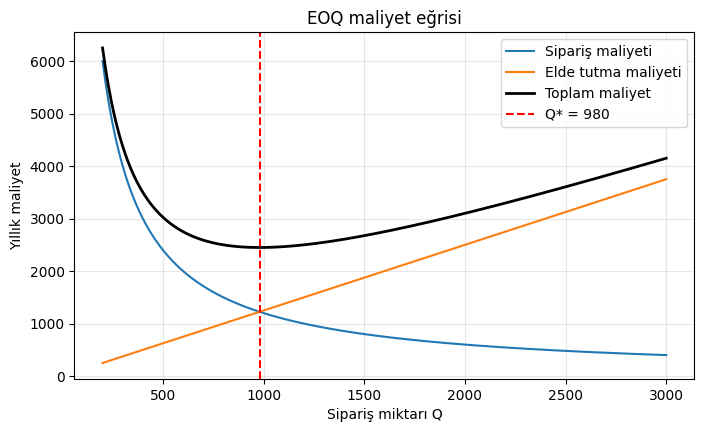

In [3]:
Q = np.linspace(200, 3000, 400)
ordering = D * S / Q
holding = H * Q / 2

plt.plot(Q, ordering, label="Sipariş maliyeti")
plt.plot(Q, holding, label="Elde tutma maliyeti")
plt.plot(Q, ordering + holding, "k", lw=2, label="Toplam maliyet")
plt.axvline(Q_star, color="red", ls="--", label=f"Q* = {Q_star:.0f}")
plt.xlabel("Sipariş miktarı Q"); plt.ylabel("Yıllık maliyet")
plt.title("EOQ maliyet eğrisi"); plt.legend(); plt.show()

Toplam maliyet eğrisi $Q^*$ civarında oldukça **düzdür**: sipariş miktarı %20 yanlış seçilse bile
maliyet çok az artar. Aşağıda bunu sayısal olarak görelim.

In [4]:
for sapma in (-0.4, -0.2, 0, 0.2, 0.4):
    q = Q_star * (1 + sapma)
    artis = eoq_total_cost(q, D, S, H) / eoq_total_cost(Q_star, D, S, H) - 1
    print(f"Q* {sapma:+.0%} → maliyet artışı: {artis:.2%}")

Q* -40% → maliyet artışı: 13.33%
Q* -20% → maliyet artışı: 2.50%
Q* +0% → maliyet artışı: 0.00%
Q* +20% → maliyet artışı: 1.67%
Q* +40% → maliyet artışı: 5.71%


## 2. Eksik stoklu (backorder) EOQ

Eksik stoğa izin verilir ve müşteri bekler. $B$: birim başına yıllık eksik stok maliyeti olmak üzere

$$Q^* = \sqrt{\frac{2DS}{H}}\sqrt{\frac{H+B}{B}}, \qquad b^* = Q^*\frac{H}{H+B}$$

In [5]:
def eoq_with_backorders(D, S, H, B):
    Q = sqrt(2 * D * S / H) * sqrt((H + B) / B)
    b = Q * H / (H + B)
    return Q, b

rows = []
for B in (1, 2.5, 5, 10, 50):
    Qb, b = eoq_with_backorders(D, S, H, B)
    rows.append({"B (eksik stok maliyeti)": B, "Q*": round(Qb, 1), "Maks. eksik stok b*": round(b, 1)})
pd.DataFrame(rows)

,B (eksik stok maliyeti),Q*,Maks. eksik stok b*
0,1.0,1833.0,1309.3
1,2.5,1385.6,692.8
2,5.0,1200.0,400.0
3,10.0,1095.4,219.1
4,50.0,1004.0,47.8


## 3. Newsvendor (gazete satıcısı) modeli

Tek dönemlik, talebi belirsiz ürünler için (ör. günlük gazete, mevsimlik ürün):
kritik oran $CR = \dfrac{p - c}{p - s}$ ve normal talepte $Q^* = \mu + z_{CR}\,\sigma$

- $p$: satış fiyatı, $c$: birim maliyet, $s$: değerlendirme (kurtarma) değeri

In [6]:
def newsvendor_quantity(price, cost, salvage, mu, sigma):
    if not price > cost > salvage:
        raise ValueError("price > cost > salvage olmalıdır.")
    cr = (price - cost) / (price - salvage)
    return mu + NormalDist().inv_cdf(cr) * sigma, cr

p, c, s = 20, 8, 3
mu, sigma = 200, 40
Q_nv, cr = newsvendor_quantity(p, c, s, mu, sigma)
print(f"Kritik oran = {cr:.3f}  →  optimal sipariş Q* = {Q_nv:.1f}")

Kritik oran = 0.706  →  optimal sipariş Q* = 221.7


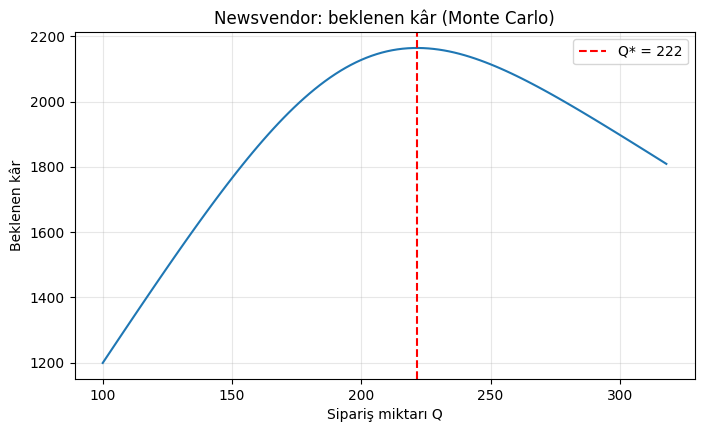

Simülasyonda en iyi Q ≈ 222  (analitik Q* = 221.7)


In [7]:
rng = np.random.default_rng(42)
talep = np.maximum(0, rng.normal(mu, sigma, 200_000))

def beklenen_kar(q):
    satis = np.minimum(q, talep)
    artan = np.maximum(q - talep, 0)
    return (p * satis + s * artan - c * q).mean()

qs = np.arange(100, 320, 2)
karlar = [beklenen_kar(q) for q in qs]

plt.plot(qs, karlar)
plt.axvline(Q_nv, color="red", ls="--", label=f"Q* = {Q_nv:.0f}")
plt.xlabel("Sipariş miktarı Q"); plt.ylabel("Beklenen kâr")
plt.title("Newsvendor: beklenen kâr (Monte Carlo)"); plt.legend(); plt.show()
print(f"Simülasyonda en iyi Q ≈ {qs[int(np.argmax(karlar))]}  (analitik Q* = {Q_nv:.1f})")

## 4. Emniyet stoğu ve (Q, r) politikası

Talep belirsiz ve tedarik süresi ($L$ gün) varsa:

- Emniyet stoğu: $SS = z\,\sigma_{gün}\sqrt{L}$
- Yeniden sipariş noktası: $r = \mu_{gün}L + SS$
- Envanter pozisyonu $r$'ye düşünce $Q$ birim sipariş verilir

In [8]:
def safety_stock(service_level, sigma_daily, L):
    return NormalDist().inv_cdf(service_level) * sigma_daily * sqrt(L)

def qr_policy(D, S, H, L, sigma_daily, service_level=0.95, days=365):
    Q = eoq(D, S, H)
    mu_daily = D / days
    ss = safety_stock(service_level, sigma_daily, L)
    return {"Q": Q, "r": mu_daily * L + ss, "SS": ss, "mu_gun": mu_daily}

L, sigma_d = 7, 20
pol = qr_policy(D, S, H, L, sigma_d, service_level=0.95)
print({k: round(v, 1) for k, v in pol.items()})

{'Q': 979.8, 'r': 317.2, 'SS': 87.0, 'mu_gun': 32.9}


## 5. Simülasyon: envanter seviyesi

Analitik formüller varsayımlara dayanır. Simülasyon ile politikayı **gerçekçi (rastgele) talep** altında deneriz.
Varsayımlar: günlük talep ~ Normal($\mu$, $\sigma$), karşılanamayan talep **kayıp satış**, tedarik süresi sabit.

In [9]:
def simulate(order_rule, init_stock, mu, sigma, L, days=365, h=0.01, K=100.0, pen=3.0, seed=0, record=False):
    """order_rule(envanter_pozisyonu) -> sipariş miktarı (0 ise sipariş yok)."""
    rng = np.random.default_rng(seed)
    on_hand, pipeline = init_stock, []
    hold = order = short = unmet = total = 0.0
    n_orders, path = 0, []
    for t in range(days):
        on_hand += sum(q for a, q in pipeline if a == t)
        pipeline = [(a, q) for a, q in pipeline if a != t]
        d = max(0.0, rng.normal(mu, sigma))
        total += d
        sold = min(on_hand, d)
        on_hand -= sold
        lost = d - sold
        unmet += lost; short += pen * lost; hold += h * on_hand
        pos = on_hand + sum(q for _, q in pipeline)
        qty = order_rule(pos)
        if qty > 0:
            pipeline.append((t + L, qty)); order += K; n_orders += 1
        if record:
            path.append(on_hand)
    res = {
        "gunluk_maliyet": (hold + order + short) / days,
        "fill_rate": 1 - unmet / total,
        "siparis_sayisi": n_orders,
    }
    return (res, path) if record else res

mu_d = D / 365
h_gun = H / 365
Q_p, r_p = pol["Q"], pol["r"]

sonuc, yol = simulate(lambda pos: Q_p if pos <= r_p else 0.0, Q_p + r_p, mu_d, sigma_d, L,
                      h=h_gun, K=S, pen=3.0, record=True)
print({k: round(v, 3) for k, v in sonuc.items()})

{'gunluk_maliyet': 7.316, 'fill_rate': 1.0, 'siparis_sayisi': 12}


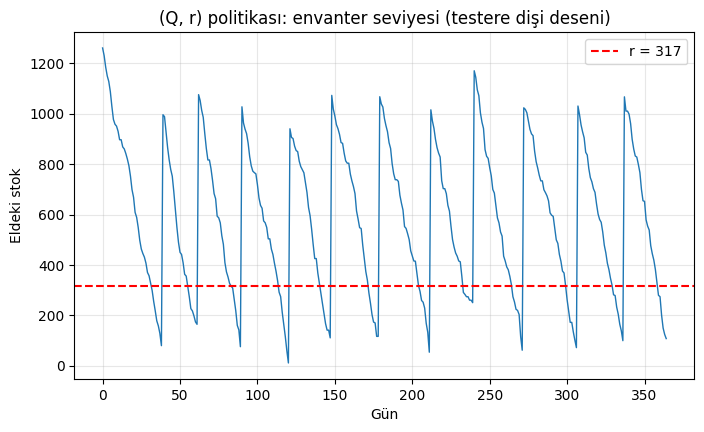

In [10]:
plt.plot(yol, lw=1)
plt.axhline(r_p, color="red", ls="--", label=f"r = {r_p:.0f}")
plt.xlabel("Gün"); plt.ylabel("Eldeki stok")
plt.title("(Q, r) politikası: envanter seviyesi (testere dişi deseni)")
plt.legend(); plt.show()

## 6. Maliyet – hizmet düzeyi dengesi

Hizmet düzeyi (emniyet stoğu) arttıkça eksik stok azalır ama elde tutma maliyeti artar.
Her hizmet düzeyi için 30 farklı rastgele senaryo çalıştırıp ortalama alıyoruz. Sonuçlar eksik stok cezasına ($3$/birim) ve diğer parametrelere bağlıdır.

In [11]:
seviyeler = [0.70, 0.80, 0.90, 0.95, 0.99]
rows = []
for sl in seviyeler:
    pl = qr_policy(D, S, H, L, sigma_d, service_level=sl)
    sonuclar = [simulate(lambda pos, pl=pl: pl["Q"] if pos <= pl["r"] else 0.0,
                         pl["Q"] + pl["r"], mu_d, sigma_d, L, h=h_gun, K=S, pen=3.0, seed=sd)
                for sd in range(30)]
    ort = pd.DataFrame(sonuclar).mean()
    rows.append({"hedef hizmet düzeyi": sl, "r": round(pl["r"], 1),
                 "günlük maliyet": round(ort["gunluk_maliyet"], 3),
                 "fill rate": round(ort["fill_rate"], 4)})
tablo = pd.DataFrame(rows)
tablo

,hedef hizmet düzeyi,r,günlük maliyet,fill rate
0,0.70,257.9,7.496,0.9939
1,0.80,274.7,7.352,0.9966
2,0.90,298.0,7.262,0.9990
3,0.95,317.2,7.314,0.9998
4,0.99,353.2,7.539,1.0000


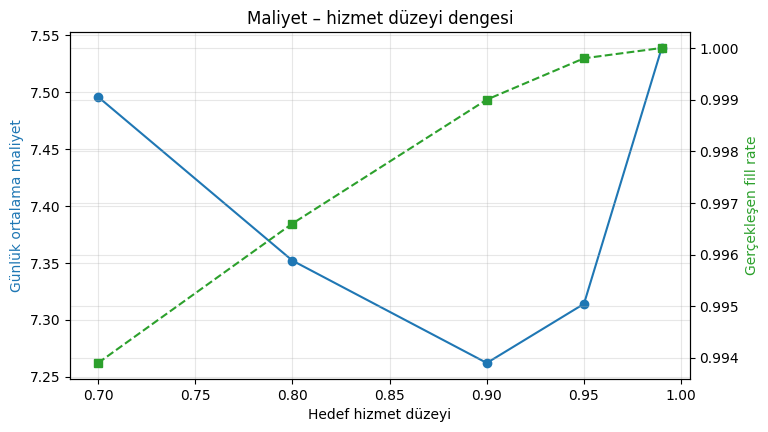

In [12]:
fig, ax1 = plt.subplots()
ax1.plot(tablo["hedef hizmet düzeyi"], tablo["günlük maliyet"], "o-", color="tab:blue")
ax1.set_xlabel("Hedef hizmet düzeyi"); ax1.set_ylabel("Günlük ortalama maliyet", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(tablo["hedef hizmet düzeyi"], tablo["fill rate"], "s--", color="tab:green")
ax2.set_ylabel("Gerçekleşen fill rate", color="tab:green")
plt.title("Maliyet – hizmet düzeyi dengesi"); plt.show()

## 7. ABC analizi (Pareto)

Ürünler yıllık parasal değerlerine göre sıralanır: **A** (ilk %80 değer), **B** (sonraki %15), **C** (kalan %5).
A sınıfı ürünlere daha sıkı stok kontrolü uygulanır.

> Aşağıdaki veri **örnek olarak üretilmiştir**; gerçek bir veri setiyle değiştirilebilir.

In [13]:
rng = np.random.default_rng(1)
n = 40
df = pd.DataFrame({
    "urun": [f"U{i:02d}" for i in range(1, n + 1)],
    "yillik_deger": rng.lognormal(mean=8, sigma=1.7, size=n),
})

def abc_analysis(df, a_cut=0.80, b_cut=0.95):
    out = df.sort_values("yillik_deger", ascending=False).reset_index(drop=True)
    out["kumulatif_pay"] = out["yillik_deger"].cumsum() / out["yillik_deger"].sum()
    onceki = out["kumulatif_pay"].shift(fill_value=0)
    out["sinif"] = onceki.apply(lambda x: "A" if x < a_cut else ("B" if x < b_cut else "C"))
    return out

abc = abc_analysis(df)
print(abc["sinif"].value_counts().sort_index().to_string())
abc.head(10)

sinif
A    11
B    13
C    16


,urun,yillik_deger,kumulatif_pay,sinif
0,U31,109133.358252,0.280544,A
1,U34,96058.410942,0.527477,A
2,U23,26900.724128,0.596629,A
3,U24,16505.209478,0.639058,A
4,U05,13892.507894,0.674771,A
5,U02,12049.167434,0.705745,A
6,U36,9202.290809,0.729401,A
7,U35,8949.877227,0.752408,A
8,U16,8250.578198,0.773618,A
9,U08,8005.633634,0.794197,A


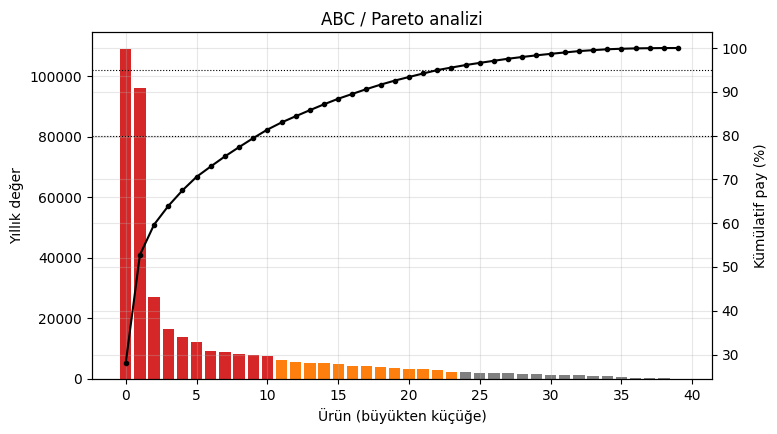

In [14]:
renk = {"A": "tab:red", "B": "tab:orange", "C": "tab:gray"}
fig, ax = plt.subplots()
ax.bar(abc.index, abc["yillik_deger"], color=[renk[k] for k in abc["sinif"]])
ax.set_ylabel("Yıllık değer"); ax.set_xlabel("Ürün (büyükten küçüğe)")
ax2 = ax.twinx()
ax2.plot(abc.index, abc["kumulatif_pay"] * 100, "k-o", ms=3)
ax2.axhline(80, color="k", ls=":", lw=0.8); ax2.axhline(95, color="k", ls=":", lw=0.8)
ax2.set_ylabel("Kümülatif pay (%)")
plt.title("ABC / Pareto analizi"); plt.show()

## Sonuç ve olası geliştirmeler

- EOQ maliyet eğrisi $Q^*$ civarında düzdür; küçük sapmalar maliyeti çok etkilemez.
- (Q, r) politikasında hizmet düzeyi arttıkça eksik stok maliyeti azalır ama emniyet stoğu maliyeti artar; simülasyonda toplam maliyet orta bir hizmet düzeyinde (bu parametrelerle yaklaşık %90) en düşük çıktı.
- ABC analizi, sınırlı dikkatin hangi ürünlere ayrılacağını belirler.

**Sonraki adımlar**
- [ ] Çok kalemli / kapasite kısıtlı sipariş problemi (doğrusal programlama, PuLP)
- [ ] Gerçek talep verisiyle tahmin + politika karşılaştırması
- [ ] (s, S) politikası ile (Q, r) karşılaştırması